In [1]:
import pandas as pd # used for data handling

In [2]:
import numpy as np # numpy used for numerical calculations

In [3]:
import matplotlib.pyplot as plt #matplotlib used for data visualization

In [4]:
from sklearn.model_selection import train_test_split #random shuffle ,split

In [5]:
from sklearn.linear_model import LinearRegression


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
from sklearn.datasets import load_diabetes

In [8]:
diabetes = load_diabetes()

In [9]:
print(type(diabetes))

<class 'sklearn.utils._bunch.Bunch'>


In [10]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [ ]:
print(diabetes.DESCR)

In [12]:
print(diabetes.feature_names)# name of columns

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [13]:
df=pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

In [14]:
df['target']=diabetes.target

In [15]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [16]:
df.tail()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [17]:
print("Row:  ",df.shape[0])

Row:   442


In [18]:
print("Column:  ",df.shape[1])

Column:   11


In [19]:
df.info

<bound method DataFrame.info of           age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  target  

In [ ]:
df.describe().T #transform

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [21]:
df.isnull().sum() #count of null values

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [24]:
x=df[["bmi"]]
y=df['target']

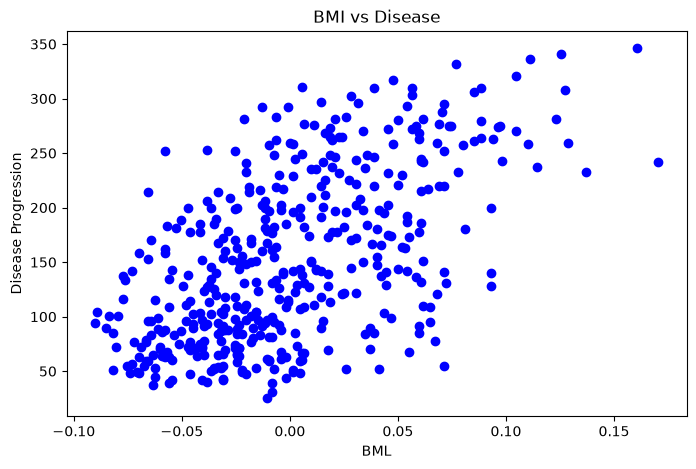

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(x,y,color='blue')
plt.xlabel("BML")
plt.ylabel("Disease Progression")
plt.title("BMI vs Disease")
plt.show()

In [26]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,
    random_state=42
)

In [27]:
len(x_train)

353

In [28]:
len(x_test)

89

In [29]:
model= LinearRegression()

In [30]:
model.fit(x_train,y_train) #train model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[998.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['bmi']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [31]:
y_pred= model.predict(x_test)

In [32]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
comparison.head(20)

,Actual,Predicted
0,219.0,145.806227
1,70.0,188.857390
2,202.0,147.958785
3,230.0,203.925298
4,111.0,131.814599
5,84.0,127.509482
6,242.0,322.315998
7,272.0,197.467623
8,94.0,61.856458
9,96.0,167.331809


In [33]:
mae=mean_absolute_error(y_test,y_pred)# It tells the average mistake your model makes

In [34]:
mse =mean_squared_error(y_test,y_pred)#errors more then penalty high

In [35]:
r2=r2_score(y_test,y_pred)# Accurate result

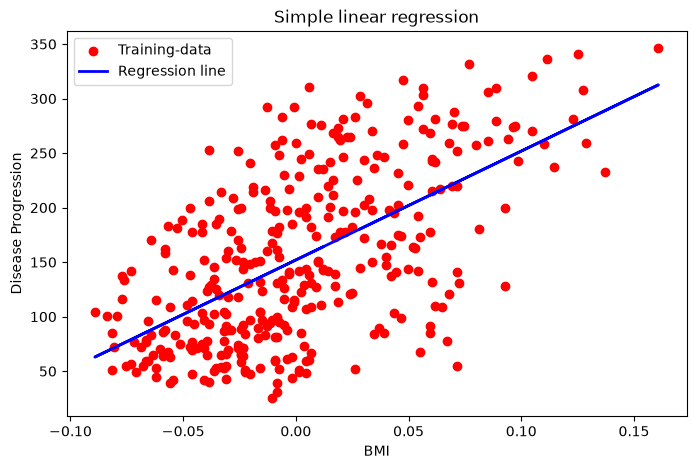

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(x_train,y_train,color= "red" ,label="Training-data")

plt.plot(x_train,model.predict(x_train),color="blue",label="Regression line",linewidth=2)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple linear regression")
plt.legend()
plt.show()

In [39]:
new_b = [[0.04]]
prediction = model.predict(new_b)
print(prediction)

[191.94646178]


c:\Users\Shikhar Srivastava\OneDrive\Desktop\AI_VIrtual_Internship\Pbel\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# hours   marks
# 1       30
# 2       40


In [40]:
df = pd.DataFrame({
    'Hours':[1,2,3,4,5,6,7,8],
    'Marks':[30,40,45,55,65,72,80,88]
})

print(df)

   Hours  Marks
0      1     30
1      2     40
2      3     45
3      4     55
4      5     65
5      6     72
6      7     80
7      8     88


In [41]:
# ip and op 
x = df[['Hours']]
y = df['Marks']


In [46]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [47]:


print("x_train")
print(x_train)

print("\nx_test")
print(x_test)

print("\ny_train")
print(y_train)

print("\ny_test")
print(y_test)

x_train
   Hours
0      1
7      8
2      3
4      5
3      4
6      7

x_test
   Hours
1      2
5      6

y_train
0    30
7    88
2    45
4    65
3    55
6    80
Name: Marks, dtype: int64

y_test
1    40
5    72
Name: Marks, dtype: int64


In [48]:
#create model
model = LinearRegression()

In [49]:
#Train Model
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.4]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [51]:
#slope and intercept
print("Slope =", model.coef_[0])
print("Intercept =", model.intercept_)

Slope = 8.399999999999997
Intercept = 21.30000000000001


In [53]:
#Predict test data
y_pred = model.predict(x_test)

print("Actual:", list(y_test))
print("Predicted:", y_pred)

Actual: [40, 72]
Predicted: [38.1 71.7]


In [54]:
#Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("R2 Score =", r2)

MAE = 1.1000000000000014
R2 Score = 0.9927734375


In [55]:
#Predict for 9 hrs
new_hours = pd.DataFrame({'Hours': [9]})

prediction = model.predict(new_hours)

print("Predicted Marks =", prediction[0])

Predicted Marks = 96.89999999999998


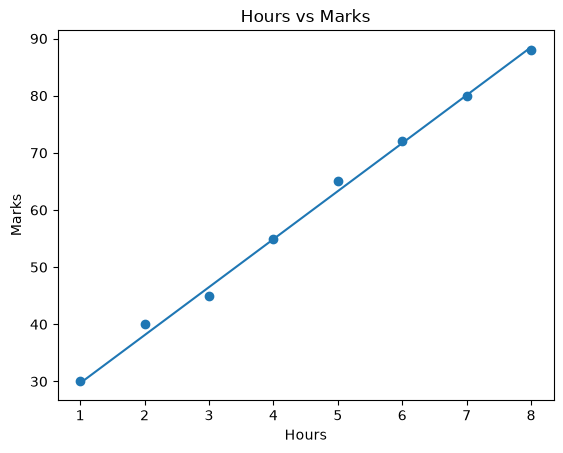

In [58]:
#Plot regression line
plt.scatter(x, y)
plt.plot(x, model.predict(x))
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

In [ ]:
#multiple linear reg -when one op depend on multiple input
#eg house prediction
#sLR y=mx+c
#MLR y=bo+b1x1+b2x2.....b2xn
#why bcz it has multiple indep var.
#y = op
#bo = intercept
#b1b2b3 = coeff
#x1x2x3 =features 

# Practical1

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score # metrices check accuracy,error etc.

In [6]:
housing = fetch_california_housing()

In [7]:
print(type(housing))

<class 'sklearn.utils._bunch.Bunch'>


In [8]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [9]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [10]:
df = pd.DataFrame(
    housing.data,
    columns = housing.feature_names
)

In [11]:
df['HousePrice']=housing.target

In [12]:
df.head(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [13]:
df.tail(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20630,3.5673,11.0,5.932584,1.134831,1257.0,2.824719,39.29,-121.32,1.120
20631,3.5179,15.0,6.145833,1.141204,1200.0,2.777778,39.33,-121.40,1.072
20632,3.1250,15.0,6.023377,1.080519,1047.0,2.719481,39.26,-121.45,1.156
20633,2.5495,27.0,5.445026,1.078534,1082.0,2.832461,39.19,-121.53,0.983
20634,3.7125,28.0,6.779070,1.148256,1041.0,3.026163,39.27,-121.56,1.168
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [14]:
print(df.shape)

(20640, 9)


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [17]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
corr = df.corr()

In [20]:
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [21]:
corr['HousePrice'].sort_values(ascending=False)

HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64

In [22]:
X = df.drop('HousePrice' ,axis=1)

In [23]:
y = df["HousePrice"]

In [24]:
print(X.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')


In [25]:
print(y.head())

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HousePrice, dtype: float64


In [26]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=40)

In [27]:
print(x_train.shape)

(16512, 8)


In [28]:
print(x_test.shape)

(4128, 8)


In [29]:
print(y_train.shape)

(16512,)


In [30]:
print(y_test.shape)

(4128,)


In [31]:
model = LinearRegression()

In [32]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.43, 0.01,-0.1 ,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-36.84
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [33]:
print(model.intercept_)

-36.84337456381572


In [34]:
y_pred = model.predict(x_test)

In [35]:
comparison= pd.DataFrame({
    'Actual': y_test.values,
    'Predict': y_pred
})
comparison.head(15)

,Actual,Predict
0,2.26500,2.004130
1,1.96200,2.575619
2,1.45800,1.197698
3,4.20000,1.689343
4,2.57800,2.187609
5,1.44100,2.138624
6,3.47400,2.820414
7,1.85400,1.626702
8,4.32100,3.145142
9,2.88200,3.016335


In [36]:
mae = mean_absolute_error(y_test,y_pred)

In [37]:
mae

0.5389572480554758

In [38]:
mse = mean_squared_error(y_test,y_pred)

In [39]:
mse

0.5417517275769406

In [40]:
r2 = r2_score(y_test,y_pred)

In [41]:
r2

0.6075794091011186

In [42]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [43]:
#to convert to df 
new_house =[[
   8,20,6,5,1,1000,3.0,34.2
]]
prediction_new_house = model.predict(new_house)
prediction_new_house[0]

c:\Users\Shikhar Srivastava\OneDrive\Desktop\AI_VIrtual_Internship\Pbel\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(-51.5298537875467)

In [44]:
residuals =y_test-y_pred
residuals

6607     0.260870
884     -0.613619
9457     0.260302
18681    2.510657
4654     0.390391
           ...   
19314   -0.721410
15433   -0.186461
3631    -0.609609
3689     0.101141
11895   -0.535655
Name: HousePrice, Length: 4128, dtype: float64

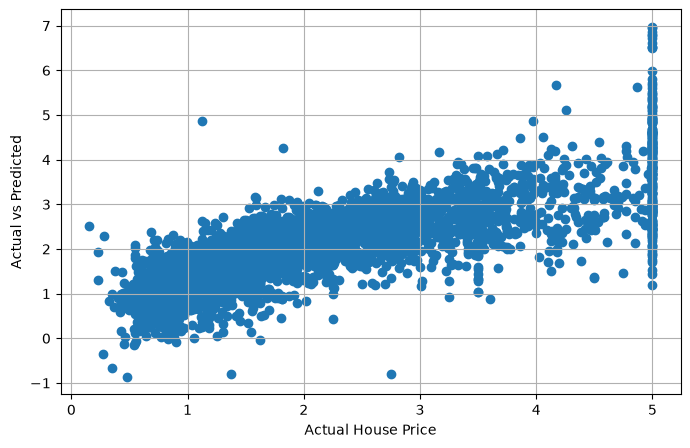

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Actual vs Predicted")
plt.grid(True)
plt.show()

In [ ]:
# new ques 
#exp    education   skills  salary


In [46]:
data={
    'Experience':[1,2,3,4,5,6],
    'Education':[12,12,15,16,18,18],
    'skills':[2,3,4,5,6,7],
    'salary': [25000,30000,38000,47000,60000,70000]

}
df= pd.DataFrame(data)
print(df)

   Experience  Education  skills  salary
0           1         12       2   25000
1           2         12       3   30000
2           3         15       4   38000
3           4         16       5   47000
4           5         18       6   60000
5           6         18       7   70000


In [47]:
x=df[['Experience','Education','skills']]
y=df['salary']

In [48]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [49]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[4821.43,1142.86,4821.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Experience','Education','skills']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.361e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [50]:
print(model.intercept_)

-13607.142857142855


In [51]:
y_pred = model.predict(x_test)

In [52]:
comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted": y_pred
})
comparison.head(20)

,Actual,Predicted
0,25000,14571.428571
1,30000,24214.285714


In [53]:
predicted_salary=model.predict([[7,19,8]])
print(predicted_salary)

[80428.57142857]


c:\Users\Shikhar Srivastava\OneDrive\Desktop\AI_VIrtual_Internship\Pbel\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [54]:
print(df.columns)

Index(['Experience', 'Education', 'skills', 'salary'], dtype='str')


In [55]:
new_b=[[9,85,8]]
prediction=model.predict(new_b)
print(prediction)

[165500.]


c:\Users\Shikhar Srivastava\OneDrive\Desktop\AI_VIrtual_Internship\Pbel\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


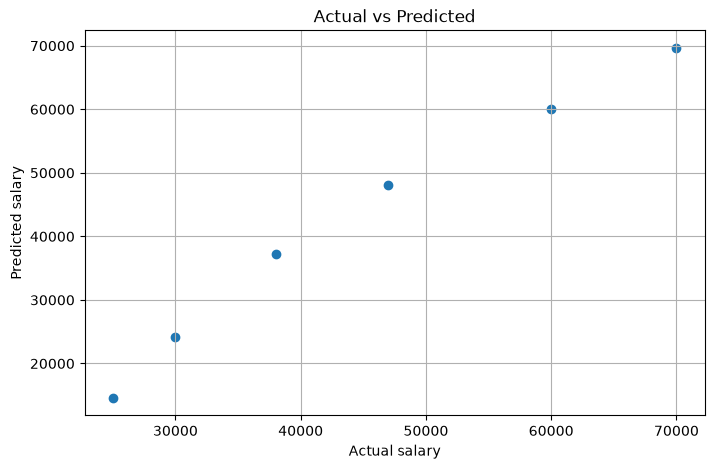

In [56]:
all_pred =model.predict(x)
plt.figure(figsize=(8,5))
plt.scatter(y,all_pred)
plt.xlabel("Actual salary")
plt.ylabel("Predicted salary")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [65]:
import pandas as pd


In [66]:
import numpy as np

In [67]:
import matplotlib.pyplot as plt

In [68]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score # metrices check accuracy,error etc.

In [69]:
data = {
    'Mileage': [15,18,20,22,25,28],
    'Engine': [1000,1200,1500,1800,2000,2200],
    'age': [2,3,5,4,6,7],
    'price':[500000,600000,750000,900000,1100000,1300000]

}

In [70]:
df = pd.DataFrame(data)
df.head()

,Mileage,Engine,age,price
0,15,1000,2,500000
1,18,1200,3,600000
2,20,1500,5,750000
3,22,1800,4,900000
4,25,2000,6,1100000


In [71]:
x = df[['Mileage', 'Engine', 'age']]

In [72]:
y = df['price']

In [73]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.30,
    random_state=42
)

In [74]:
model = LinearRegression()

In [75]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[60000., 100., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Mileage','Engine','age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [76]:
print(model.intercept_)

-600000.0


In [77]:
y_pred = model.predict(x_test)
print(y_pred)

[400000. 600000.]


In [78]:
result = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})
print(result)

   Actual  Predicted
0  500000   400000.0
1  600000   600000.0


In [79]:
mae= mean_absolute_error(y_test,y_pred)
mae

50000.000000000175

In [80]:
mse= mean_squared_error(y_test,y_pred)
mse

5000000000.000011

In [81]:
r2=r2_score(y_test,y_pred)# Accurate result
r2

-1.0000000000000044

In [82]:
df.isnull().sum()

Mileage    0
Engine     0
age        0
price      0
dtype: int64

In [83]:
df.duplicated().sum()

np.int64(0)

In [84]:
new_price= [[
    24,1800,5
]]# Data frame mein convert karne ke liye
prediction_new_price= model.predict(new_price)
prediction_new_price[0]

c:\Users\Shikhar Srivastava\OneDrive\Desktop\AI_VIrtual_Internship\Pbel\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(1019999.9999999998)

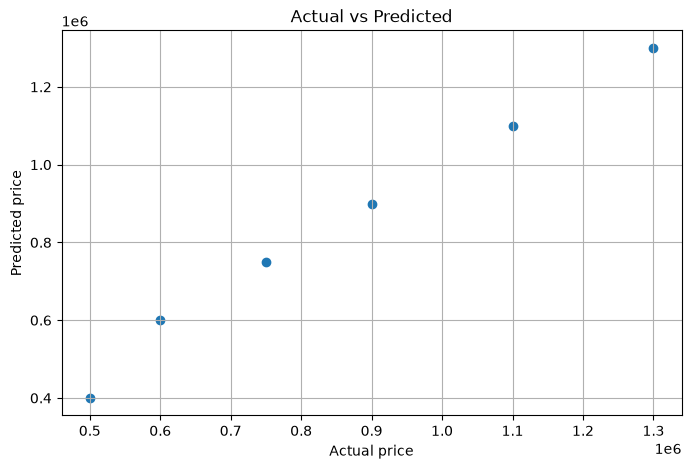

In [85]:
all_pred =model.predict(x)
plt.figure(figsize=(8,5))
plt.scatter(y,all_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()